In [7]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [8]:
img_size = 48
batch_size = 64

In [13]:
train_dir = "D:/MoodMate/data/fer2013/train"
test_dir = "D:/MoodMate/data/fer2013/test"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical"
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical"
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [14]:
print(train_generator.class_indices)

{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


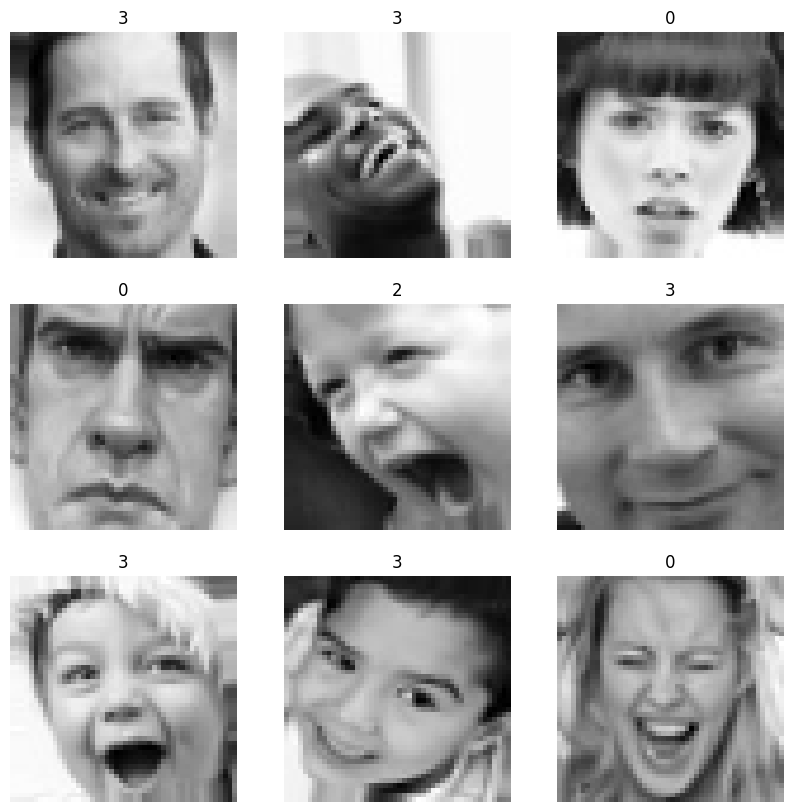

In [15]:
import numpy as np
import matplotlib.pyplot as plt

images, labels = next(train_generator)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i].reshape(48,48), cmap='gray')
    plt.title(np.argmax(labels[i]))
    plt.axis('off')

plt.show()

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

model = Sequential()

# Proper Input Layer
model.add(Input(shape=(48,48,1)))

# First Convolution Block
model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Second Convolution Block
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Third Convolution Block
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Flatten
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output Layer (7 emotions)
model.add(Dense(7, activation='softmax'))

In [18]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ Layer (type)             ┃ Output Shape      ┃   Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)        │ (None, 46, 46,    │       320 │
│                          │ 32)               │           │
├──────────────────────────┼───────────────────┼───────────┤
│ max_pooling2d_3          │ (None, 23, 23,    │         0 │
│ (MaxPooling2D)           │ 32)               │           │
├──────────────────────────┼───────────────────┼───────────┤
│ conv2d_4 (Conv2D)        │ (None, 21, 21,    │    18,496 │
│                          │ 64)               │           │
├──────────────────────────┼───────────────────┼───────────┤
│ max_pooling2d_4          │ (None, 10, 10,    │         0 │
│ (MaxPooling2D)           │ 64)               │           │
├──────────────────────────┼───────────────────┼───────────┤
│ conv2d_5 (Conv2D)        │ (None, 8, 8, 128) │    73,856 │
├──────────────────────────┼───────────────────┼───────────┤
│ max_pooling2d_5          │ (None, 4, 4, 128) │         0 │
│ (MaxPooling2D)           │                   │           │
├──────────────────────────┼───────────────────┼───────────┤
│ flatten_1 (Flatten)      │ (None, 2048)      │         0 │
├──────────────────────────┼───────────────────┼───────────┤
│ dense_2 (Dense)          │ (None, 128)       │   262,272 │
├──────────────────────────┼───────────────────┼───────────┤
│ dropout_1 (Dropout)      │ (None, 128)       │         0 │
├──────────────────────────┼───────────────────┼───────────┤
│ dense_3 (Dense)          │ (None, 7)         │       903 │
└──────────────────────────┴───────────────────┴───────────┘

 Total params: 355,847 (1.36 MB)

 Trainable params: 355,847 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=test_generator
)

Epoch 1/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 991s 2s/step - accuracy: 0.2756 - loss: 1.7728 - val_accuracy: 0.3770 - val_loss: 1.6308
Epoch 2/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 117s 261ms/step - accuracy: 0.3790 - loss: 1.5984 - val_accuracy: 0.4419 - val_loss: 1.4559
Epoch 3/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 115s 256ms/step - accuracy: 0.4300 - loss: 1.4845 - val_accuracy: 0.4826 - val_loss: 1.3569
Epoch 4/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 114s 255ms/step - accuracy: 0.4649 - loss: 1.4032 - val_accuracy: 0.4975 - val_loss: 1.2942
Epoch 5/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 116s 258ms/step - accuracy: 0.4808 - loss: 1.3595 - val_accuracy: 0.5160 - val_loss: 1.2514
Epoch 6/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 117s 260ms/step - accuracy: 0.4921 - loss: 1.3293 - val_accuracy: 0.5167 - val_loss: 1.2480
Epoch 7/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 116s 257ms/step - accuracy: 0.5094 - loss: 1.3005 - val_accuracy: 0.5305 - val_loss: 1.2177
Epoch 8/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 116s 257ms/step - accuracy: 0.5104 - lo

In [22]:
test_loss, test_acc = model.evaluate(test_generator)
print("Final Test Accuracy:", test_acc)

113/113 ━━━━━━━━━━━━━━━━━━━━ 15s 128ms/step - accuracy: 0.5621 - loss: 1.1531
Final Test Accuracy: 0.562134325504303


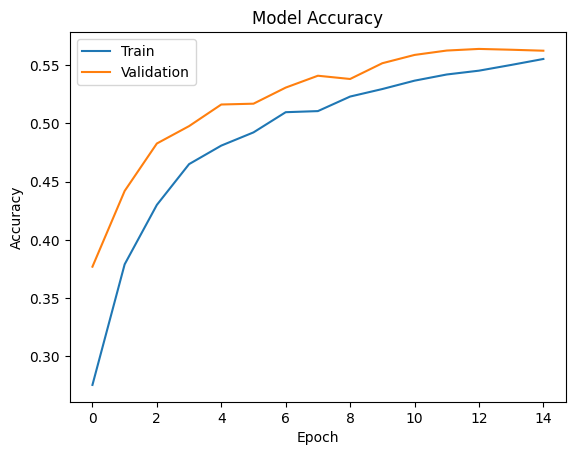

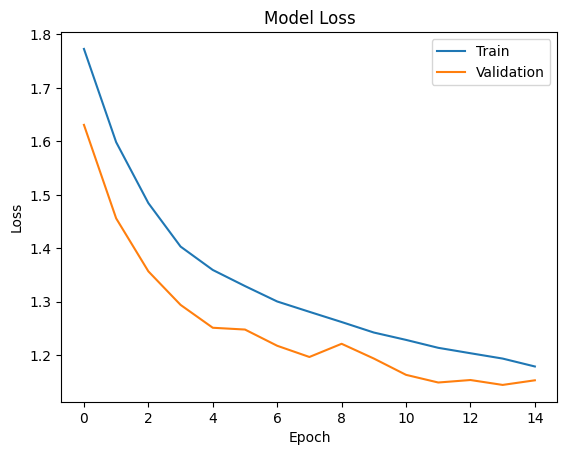

In [23]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"])
plt.show()

In [25]:
model.save("emotion_model.keras")

In [1]:
import cv2
print("OpenCV installed successfully")

OpenCV installed successfully


In [3]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

# Load trained model
model = load_model("D:\MoodMate\models\emotion_model.keras")

# Emotion labels (must match training order)
emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

# Load Haar Cascade face detector
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

# Open webcam (try 0 first, if not working change to 1)
cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)

if not cap.isOpened():
    print("Camera not accessible")
    exit()

print("Press Q to exit")

while True:
    ret, frame = cap.read()

    if not ret:
        print("Failed to grab frame")
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    for (x, y, w, h) in faces:
        face = gray[y:y+h, x:x+w]
        face = cv2.resize(face, (48, 48))
        face = face / 255.0
        face = np.reshape(face, (1, 48, 48, 1))

        # Predict emotion
        prediction = model.predict(face, verbose=0)
        emotion = emotion_labels[np.argmax(prediction)]

        # Draw rectangle
        cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)

        # Put emotion text
        cv2.putText(frame, emotion, (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.9, (0, 255, 0), 2)

    cv2.imshow("MoodMate - Emotion Detector", frame)

    # Press Q to exit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

C:\Users\nskum\anaconda3\envs\moodmate\lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Press Q to exit


KeyboardInterrupt: 

In [2]:
import pandas as pd

df = pd.read_csv("spotify_millsongdata.csv")

df.head()

,artist,song,link,text
0,ABBA,Ahe's My Kind Of Girl,/a/abba/ahes+my+kind+of+girl_20598417.html,"Look at her face, it's a wonderful face \r\nA..."
1,ABBA,"Andante, Andante",/a/abba/andante+andante_20002708.html,"Take it easy with me, please \r\nTouch me gen..."
2,ABBA,As Good As New,/a/abba/as+good+as+new_20003033.html,I'll never know why I had to go \r\nWhy I had...
3,ABBA,Bang,/a/abba/bang_20598415.html,Making somebody happy is a question of give an...
4,ABBA,Bang-A-Boomerang,/a/abba/bang+a+boomerang_20002668.html,Making somebody happy is a question of give an...


In [3]:
df.columns

Index(['artist', 'song', 'link', 'text'], dtype='object')

In [4]:
df = df[['artist', 'song', 'text']]
df = df.dropna()
df = df.sample(5000, random_state=42)  # reduce size for faster processing
df.reset_index(drop=True, inplace=True)

df.head()

,artist,song,text
0,Wishbone Ash,Right Or Wrong,Like to have you 'round \r\nWith all the lies...
1,Aerosmith,This Little Light Of Mine,"This Little Light of Mine (Light of Mine), \r..."
2,Fall Out Boy,"Dance, Dance",She says she's no good with words but I'm wors...
3,Janis Joplin,Easy Rider,"Hey mama, mama, come a look at sister, \r\nSh..."
4,Moody Blues,Peak Hour,I see it all through my window it seems. \r\n...


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

tfidf_matrix = tfidf.fit_transform(df['text'])

print(tfidf_matrix.shape)

(5000, 5000)


In [6]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix)

In [7]:
def recommend_songs(song_title, num_recommendations=5):
    idx = df[df['song'] == song_title].index
    
    if len(idx) == 0:
        return "Song not found"
    
    idx = idx[0]
    
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    sim_scores = sim_scores[1:num_recommendations+1]
    
    song_indices = [i[0] for i in sim_scores]
    
    return df[['artist', 'song']].iloc[song_indices]

In [9]:
from recommendation import df

print(df['song'].head(20))

0                          Right Or Wrong
1               This Little Light Of Mine
2                            Dance, Dance
3                              Easy Rider
4                               Peak Hour
5                                 Crazier
6                              Temptation
7                     Kiss Me At Midnight
8                    Little Black Sandals
9     I Keep Dreaming Of You All The Time
10                       Blood In My Eyes
11                                 I Am I
12                                Hold On
13                        Pinball Cha Cha
14                                Kill It
15                         I Feel For You
16                            Dareh Meyod
17                       Right Where I Am
18                              It's Hard
19                             Hallelujah
Name: song, dtype: object


In [11]:
from recommendation import recommend_songs
print(recommend_songs("Crazier"))

             artist                                       song
3860    Johnny Cash                     I Feel Better All Over
2946  Kylie Minogue                             I Feel For You
2328    Dean Martin  Better Than A Dream (feat. Judy Holliday)
2921        Roxette                      Better Off On Her Own
4280    Demi Lovato                           Our Time Is Here


In [12]:
def recommend_songs(song_title, num_recommendations=5):
    matches = df[df['song'].str.contains(song_title, case=False, na=False)]
    
    if matches.empty:
        return "Song not found"
    
    idx = matches.index[0]
    
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    sim_scores = sim_scores[1:num_recommendations+1]
    
    song_indices = [i[0] for i in sim_scores]
    
    return df[['artist', 'song']].iloc[song_indices]

In [15]:
def recommend_by_emotion(emotion):
    
    emotion_map = {
        "Happy": "Dance, Dance",
        "Sad": "Hallelujah",
        "Angry": "Temptation",
        "Surprise": "Crazier",
        "Neutral": "Hold On",
        "Fear": "It's Hard",
        "Disgust": "Kill It"
    }
    
    seed_song = emotion_map.get(emotion, "Hold On")
    
    print(f"\nDetected Emotion: {emotion}")
    print(f"Using Seed Song: {seed_song}\n")
    
    return recommend_songs(seed_song)

In [18]:
import recommendation
import importlib

importlib.reload(recommendation)

recommendation.recommend_by_emotion("Happy")


Detected Emotion: Happy
Using Seed Song: Dance, Dance



,artist,song
4174,New Order,Transmission
1501,Halloween,Halloween Dance
2502,Kiss,Dance All Over Your Face
78,Extreme,Decadence Dance
2804,Noa,Again And Again


In [19]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model
from recommendation import recommend_by_emotion

# Load trained model
model = load_model("models/emotion_model.keras")

# Emotion labels (must match training order)
emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

# Load Haar Cascade face detector
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

# Open webcam
cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)

if not cap.isOpened():
    print("Camera not accessible")
    exit()

print("Press Q to exit")

last_emotion = None  # To avoid repeating recommendations

while True:
    ret, frame = cap.read()

    if not ret:
        print("Failed to grab frame")
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    for (x, y, w, h) in faces:
        face = gray[y:y+h, x:x+w]
        face = cv2.resize(face, (48, 48))
        face = face / 255.0
        face = np.reshape(face, (1, 48, 48, 1))

        # Predict emotion
        prediction = model.predict(face, verbose=0)
        emotion = emotion_labels[np.argmax(prediction)]

        # Draw rectangle
        cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)

        # Put emotion text
        cv2.putText(frame, emotion, (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.9, (0, 255, 0), 2)

        # Only recommend if emotion changes
        if emotion != last_emotion:
            print("\n==============================")
            recommendations = recommend_by_emotion(emotion)
            print(recommendations)
            print("==============================\n")
            last_emotion = emotion

    cv2.imshow("MoodMate - Emotion Detector", frame)

    # Press Q to exit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

C:\Users\nskum\anaconda3\envs\moodmate\lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Press Q to exit


Detected Emotion: Sad
Using Seed Song: Hallelujah

               artist                  song
769     Leonard Cohen            Hallelujah
774     Planetshakers  It's All About Jesus
3856  Religious Music      Christmas Anthem
4623            Selah   Light Of The Stable
2271        Kari Jobe    Look Upon The Lord



Detected Emotion: Neutral
Using Seed Song: Hold On

            artist                        song
3146   Patti Smith               Gimme Shelter
2888   Pat Benatar  Hit Me With Your Best Shot
1011     Tom Jones               Gimme Shelter
1788  Foo Fighters          Baby Hold On To Me
2533  Fall Out Boy              Twin Skeletons



Detected Emotion: Sad
Using Seed Song: Hallelujah

               artist                  song
769     Leonard Cohen            Hallelujah
774     Planetshakers  It's All About Jesus
3856  Religious Music      Christmas Anthem
4623            Selah   Light Of The Stable
2271        Kari Jobe    Look Upon The Lord



Detected 

KeyboardInterrupt: 

In [20]:
#emotions with percentage(realtime_emotion)
#runned in the anaconda prompt and got output
import cv2
import numpy as np
from tensorflow.keras.models import load_model
from recommendation import recommend_by_emotion

# Load trained model
model = load_model("models/emotion_model.keras")

# Emotion labels (must match training order)
emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

# Load Haar Cascade face detector
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

# Open webcam
cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)

if not cap.isOpened():
    print("Camera not accessible")
    exit()

print("Press Q to exit")

last_emotion = None  # To avoid repeating recommendations

while True:
    ret, frame = cap.read()

    if not ret:
        print("Failed to grab frame")
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    for (x, y, w, h) in faces:
        face = gray[y:y+h, x:x+w]
        face = cv2.resize(face, (48, 48))
        face = face / 255.0
        face = np.reshape(face, (1, 48, 48, 1))

        # Predict emotion
        prediction = model.predict(face, verbose=0)
        confidence = np.max(prediction) * 100
        emotion = emotion_labels[np.argmax(prediction)]

        # Draw rectangle
        cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)

        # Put emotion text
        text = f"{emotion} ({confidence:.2f}%)"

        cv2.putText(frame, text, (x, y-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.9, (0, 255, 0), 2)

        # Only recommend if emotion changes
        if emotion != last_emotion:
            print("\n==============================")
            recommendations = recommend_by_emotion(emotion)
            print(recommendations)
            print("==============================\n")
            last_emotion = emotion

    cv2.imshow("MoodMate - Emotion Detector", frame)

    # Press Q to exit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

C:\Users\nskum\anaconda3\envs\moodmate\lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Press Q to exit
Failed to grab frame
